In [1]:
from pathlib import Path

import anndata
from anndata import AnnData
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import RocCurveDisplay

import zs_perturbation
from zs_perturbation import BENCHMARK_FILE, CONTROL, DATASET_NAME, TO_GENE_SYMBOL, DISEASES

Loading weights:   0%|          | 0/319 [00:00<?, ?it/s]

In [2]:
# zs_perturbation.download_dataset()

In [3]:
disease = DISEASES[2]
disease

'PSO'

In [4]:
adata = zs_perturbation.load_dataset(disease)

/Users/quentinblampey/dev/zs_perturbation/zs_perturbation/io.py:22: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


In [5]:
adata_control = adata[adata.obs["disease"] == CONTROL].copy()
adata_disease = adata[adata.obs["disease"] != CONTROL].copy()

In [6]:
healthy_centroid = zs_perturbation.encode(adata_control).mean(dim=0)

Encoding:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
scores = zs_perturbation.compute_encoder_score(adata_disease, healthy_centroid)
adata.var["encoder_scores"] = scores

Gradient Computation:   0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
df_res = zs_perturbation.compute_scores(adata, disease, "encoder_scores")

Text(0.5, 1.0, 'ROC Curve for PSO')

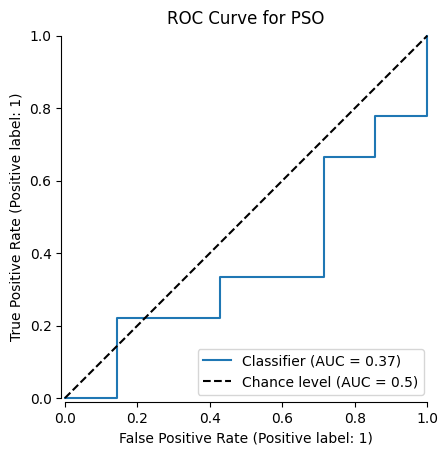

In [9]:
RocCurveDisplay.from_predictions(df_res["y_true"], df_res["y_score"], plot_chance_level=True, despine=True)
plt.title(f"ROC Curve for {disease}")

### decoder-based


In [150]:
z_holder = {}


def hook_fn(module, input, output):
    z_holder["z"] = output
    output.retain_grad()  # critical (non-leaf)


handle = model.layers[-2].register_forward_hook(hook_fn)

In [151]:
output = model.encode(**inputs)

predicted_expression = model.decode(output.gene_embeddings)

In [152]:
predicted_expression.sum().backward()

In [155]:
z_holder["z"].grad

tensor([[[-0.0885,  0.0556, -0.0829,  ...,  0.0043, -0.0523,  0.0721],
         [ 0.0036,  0.0589, -0.0242,  ..., -0.0062, -0.0119, -0.0064],
         [-0.0084,  0.0425, -0.0280,  ...,  0.0057, -0.0146, -0.0022],
         ...,
         [ 0.0751, -0.0364,  0.0356,  ..., -0.0188,  0.0414, -0.0131],
         [-0.0161,  0.1210, -0.0912,  ...,  0.0438, -0.0031, -0.0278],
         [-0.0144, -0.0236,  0.0129,  ...,  0.0032, -0.0098,  0.0204]]])